In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Question 1**

**Part (a)**

In [45]:
# Trial function
def w(x, b, x0):
    norm_const = np.sqrt(b)/np.arctan(1/np.sqrt(b))
    return norm_const * 1/(b + (x-x0)**2)

# Function to integrate
def f(x): 
    if x>0:
        return x**3/(np.exp(x) - 1)
    else:
        return 0

Checking for values of b and $x_0$

$f(x)$ peaks at $x = 1$, hence we choose $x_0 = 1$, so that the peak of $w(x)$ also occurs at $x = 1$.

$b$ controls the spread of the distribution between $x \in [0, 1]$.

The normalisation constant is obtained by $\int_0^1 w(x) \, dx = 1$

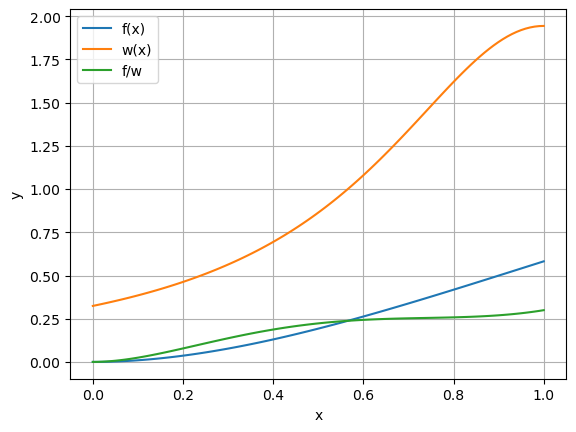

In [46]:
# Parameters
xi, xf = 0, 1
Nx = 100
xs = np.linspace(xi, xf, Nx)
fs = [f(x) for x in xs]

# Setting b and x0
b = 0.2
x0 = 1
ws = w(xs, b, x0)

# Plotting
plt.plot(xs, fs, label = "f(x)")
plt.plot(xs, ws, label = "w(x)")
plt.plot(xs, fs/ws, label = "f/w")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

**Part (b)**

Defining functions

In [47]:
# Inverse function of y(x)
def get_x(y, b):
    theta = (y-1)*np.arctan(1/np.sqrt(b))
    return 1 + np.sqrt(b)*np.tan(theta)

# f/w
def g(x, b):
    return f(x)/w(x, b, x0)

# Monte-Carlo integration of g(x)
def MC_eval_g(n, b):
    store = 0.0
    for i in range(n):
        y = np.random.rand()
        store += g(get_x(y, b), b)
    return store/n

Implementing importance sampling for different N

In [49]:
Ns = np.concatenate((np.asarray([1,2,5])*10, np.asarray([1,2,5])*100))
np.random.seed(20)
exact = 0.2248

for n in Ns:
    val = MC_eval_g(n, b)
    print("%5d  %0.7f  %0.5f" %(n, val, abs(val-exact)))

   10  0.2319801  0.00718
   20  0.2346733  0.00987
   50  0.2384166  0.01362
  100  0.2349619  0.01016
  200  0.2250824  0.00028
  500  0.2201589  0.00464
